# Monte Carlo Convergence Analysis

Run batched simulations, plot champion-probability stability vs iteration count, then set `N_SIMULATIONS_DEFAULT` in `src/config.py`.

Prerequisite: trained models in `models/` (`python train_models.py`).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.preprocessing import load_and_preprocess
from src.models import load_models
from src.simulations import run_monte_carlo_checkpoints
from src.convergence import build_convergence_history, estimate_stable_n, plot_convergence
from src.config import CONVERGENCE_BATCH_SIZE, CONVERGENCE_MAX_ITERATIONS, CONVERGENCE_TOL, CONVERGENCE_MIN_N, N_SIMULATIONS_DEFAULT
print('Project root:', ROOT)

Project root: c:\Users\mohit\OneDrive\Documents\FIFA_WC_Prediction


In [2]:
DATA_DIR = ROOT / 'data'
MODEL_DIR = ROOT / 'models'
OUT_DIR = ROOT / 'notebooks'
OUT_DIR.mkdir(exist_ok=True)

_, team_hist, elo_dict = load_and_preprocess(str(DATA_DIR))
models = load_models(str(MODEL_DIR))
print('Data and models loaded.')

Data and models loaded.


c:\Users\mohit\OneDrive\Documents\FIFA_WC_Prediction\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\mohit\OneDrive\Documents\FIFA_WC_Prediction\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator Ridge from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\mohit\OneDrive\Documents\FIFA_WC_Prediction\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle est

In [3]:
checkpoints = run_monte_carlo_checkpoints(
    team_hist=team_hist,
    elo_df=elo_dict,
    models=models,
    batch_size=CONVERGENCE_BATCH_SIZE,
    max_iterations=CONVERGENCE_MAX_ITERATIONS,
    stop_on_convergence=True,
)
print('Checkpoints recorded:', len(checkpoints))
print('Final N:', checkpoints[-1]['n_simulations'])

Checkpoints recorded: 31
Final N: 15500


In [4]:
wide, long = build_convergence_history(checkpoints)
wide.to_csv(OUT_DIR / 'convergence_history_wide.csv', index=False)
long.to_csv(OUT_DIR / 'convergence_history_long.csv', index=False)
wide.tail(10)

,n_simulations,mean_champion_prob_top_k,median_champion_prob_all,p90_champion_prob_all,max_top_k_delta
21,11000,0.091716,0.002545,0.055000,0.000433
22,11500,0.091739,0.002435,0.055278,0.000933
23,12000,0.091969,0.002500,0.055425,0.001478
24,12500,0.092000,0.002440,0.055520,0.000873
25,13000,0.092010,0.002385,0.055338,0.001169
26,13500,0.092093,0.002481,0.055341,0.001379
27,14000,0.092143,0.002429,0.055014,0.001138
28,14500,0.092121,0.002483,0.054903,0.000557
29,15000,0.092008,0.002467,0.055107,0.000538
30,15500,0.091968,0.002484,0.055168,0.000338


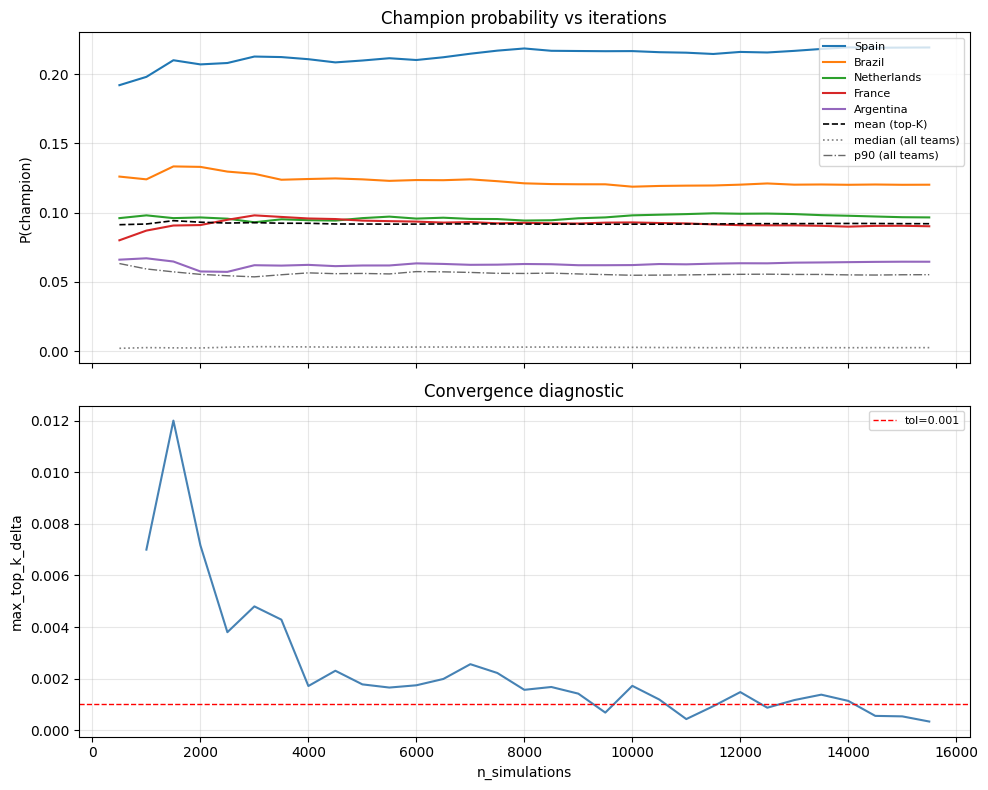

In [5]:
plot_convergence(wide, long, output_path=OUT_DIR / 'convergence_plot.png', tol=CONVERGENCE_TOL)

In [6]:
recommended = estimate_stable_n(wide, min_n=CONVERGENCE_MIN_N)
final_n = checkpoints[-1]['n_simulations']

print('Current N_SIMULATIONS_DEFAULT:', N_SIMULATIONS_DEFAULT)
print('Sweep final N:', final_n)
if recommended:
    print('Recommended stable N (advisory):', recommended)
    print('-> Update src/config.py: N_SIMULATIONS_DEFAULT =', recommended)
else:
    print('No stable N found under current tol/min_n. Inspect plot or raise CONVERGENCE_MAX_ITERATIONS.')

Current N_SIMULATIONS_DEFAULT: 10000
Sweep final N: 15500
Recommended stable N (advisory): 15500
-> Update src/config.py: N_SIMULATIONS_DEFAULT = 15500
